# Cross Signal Correlation

This will compare SBERT Similarity Score vs Soft Compatibility Labels 

we have SBERT pairwise similarities (from Experiment A) and soft compatibility scores (from Experiment B), but on different profile samples. The plan here is to re-run both on the same set of profile pairs so you can actually correlate text similarity with attribute compatibility. This tests whether semantically similar profiles (by essay text) also tend to be attribute-compatible — a core hypothesis of the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read dataset
okCupid = pd.read_csv("./data/okcupid_profiles.csv")

In [3]:
# 1. Basic info
print(okCupid.shape)
print(okCupid.dtypes)
print(okCupid.head(3).to_string())

# 2. Missing values
print(okCupid.isnull().mean().sort_values(ascending=False))

# 3. Summary stats for numeric cols
print(okCupid.describe())

# 4. Essay fields — how much text do people actually write?
essay_cols = [c for c in okCupid.columns if c.startswith('essay')]
print("Essay columns:", essay_cols)
for col in essay_cols:
    filled = okCupid[col].notna().mean()
    avg_len = okCupid[col].dropna().str.len().mean()
    print(f"{col}: {filled:.1%} filled, avg {avg_len:.0f} chars")

# 6. Categorical distributions
for col in ['sex', 'status', 'education', 'religion', 'diet']:
    print(f"\n{col}:\n", okCupid[col].value_counts(normalize=True).head(6))

(59946, 31)
age              int64
status          object
sex             object
orientation     object
body_type       object
diet            object
drinks          object
drugs           object
education       object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
pets            object
religion        object
sign            object
smokes          object
speaks          object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
dtype: object
   age     status sex orientation       body_type               diet    drinks      drugs                       education     ethnicity  height  income                   job       last_online                         location                               offspr

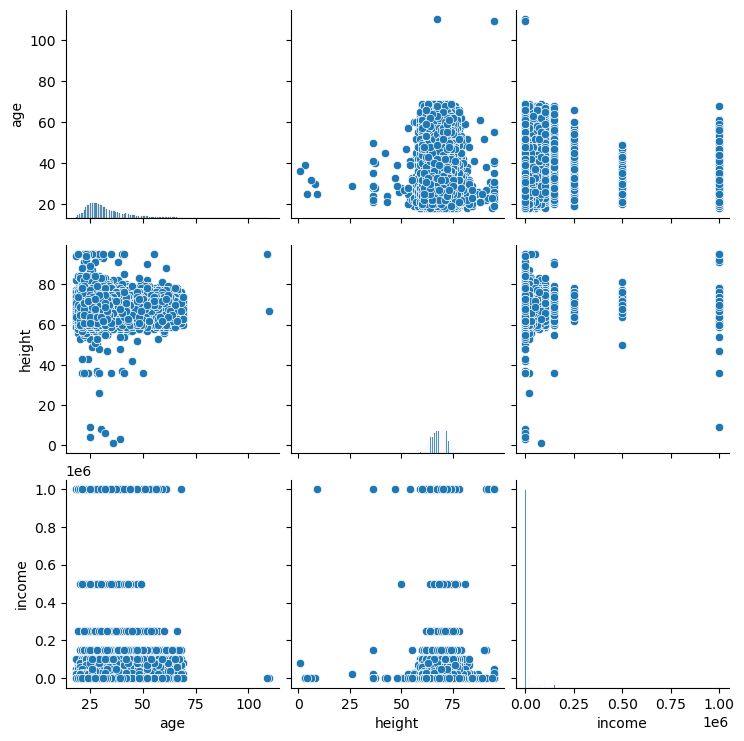

In [4]:
# 5. Scatterplot matrix of key numeric cols
numeric_cols = ['age', 'height', 'income']
sns.pairplot(okCupid[numeric_cols].dropna())
plt.savefig('pairplot.png', dpi=80)
plt.show()

# Try Fitting Some models + Setup CUDA

Setup CUDA/Hardware acceleration to make this faster

In [5]:
# ! pip install torch

In [6]:
# checing CUDA installation & hardware availability for PyTorch
import torch
print(torch.__version__)          # should be 2.x
print(torch.cuda.is_available())  # should be True
print(torch.cuda.get_device_name(0))  # should show GTX 1650 Ti (onboard GPU)
print(torch.__file__)

2.7.1+cu118
True
NVIDIA GeForce GTX 1650 Ti
c:\Users\Tengis\anaconda3\envs\ML\Lib\site-packages\torch\__init__.py


In [10]:
# Authenticate with HuggingFace token to get higher rate limits for API

with open("hugging_face_token.txt", "r") as file:
    user_token = file.readline()
    assert len(user_token) > 0 # ensure valid token was read

# Huggging Face Auth logic here...
# from huggingface_hub import login
# login(token=user_token)
# ...

## Experiment A:
Semantic Similarity Comparison

1) run TF-IDF, Word2Vec, SBERT on Essay0 + Essay4
2) compare similarity score distributions


In [11]:
# CUDA check ---
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # should print 'cuda'

# Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


Using device: cuda


Profiles with usable text: 55414
Sample size: 2000

--- TF-IDF ---
TF-IDF matrix shape: (2000, 10000)
TF-IDF similarity — mean: 0.0328, std: 0.0240

--- Word2Vec ---
Word2Vec matrix shape: (2000, 100)
Word2Vec similarity — mean: 0.9530, std: 0.0483

--- SBERT ---


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4299.84it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:07<00:00,  4.05it/s]


SBERT matrix shape: (2000, 384)
SBERT similarity — mean: 0.3518, std: 0.1404


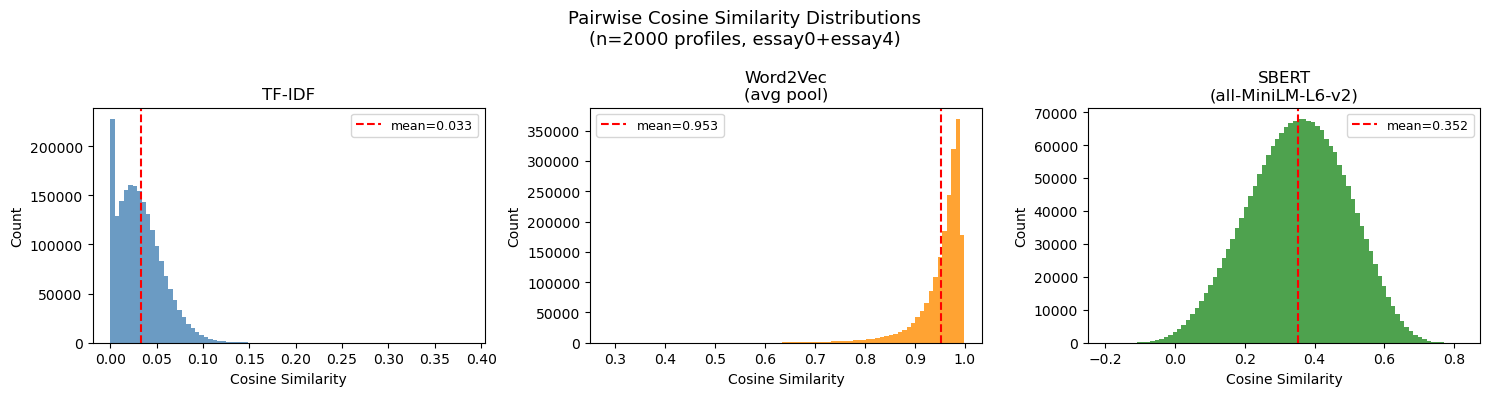

Saved: similarity_distributions.png


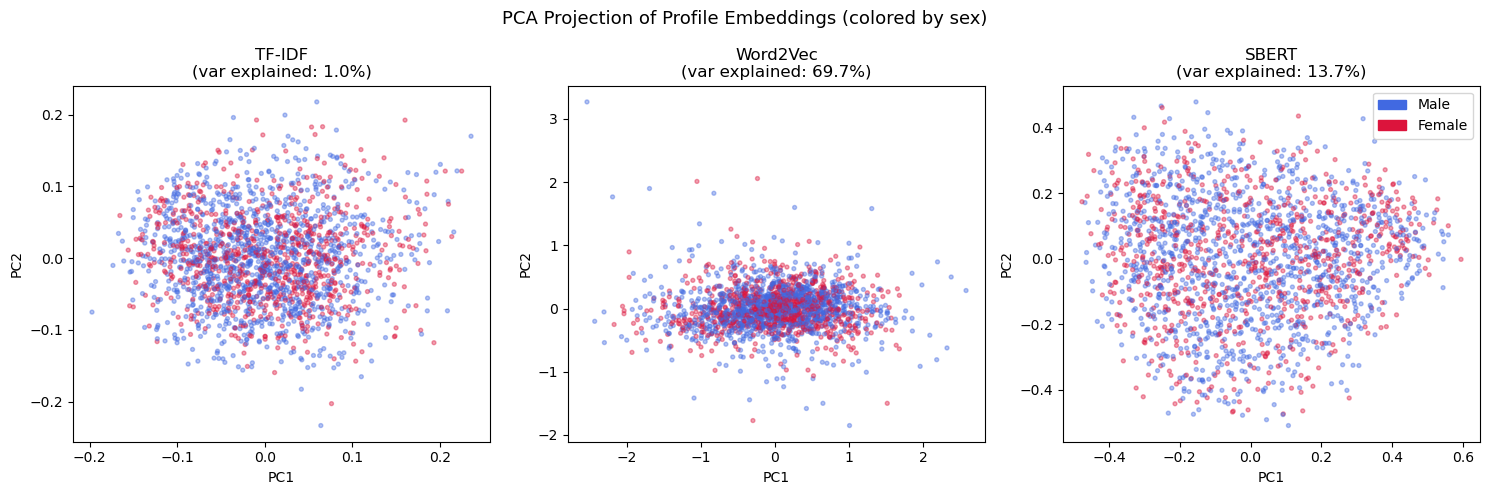

Saved: pca_projections.png

=== TOP-5 MOST SIMILAR PAIRS PER METHOD ===

[TF-IDF]
  Rank 1 (sim=0.3845):
    A: im just on here for friends & nothing more!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
    B: im half filipino and half white and im trying to live my life to the fullest don't have one...

  Rank 2 (sim=0.3578):
    A: http://www.youtube.com/watch?v=imtdwizwedu http://thefeministwire.com/2012/02/of-ambivalence-the-help-obama-and-the-ulti...
    B: while i was vacationing in japan recently, i met two separate expatriates whose lives were consistently more fun than i ...

  Rank 3 (sim=0.3543):
    A: im just on here for friends & nothing more!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
    B: im cautious and generous. im open hearted and boundaried. im learning im a terrible dishwasher.  i strive for gracefulne...

  Rank 4 (sim=0.3531):
    A: some have told me that this video is me at my best. i hope so. it's certainly me doing what i love to do the most - sell...
    B: http://www.youtube.com/wat

In [12]:
# after loading data, Combine essay0 + essay4; fill missing with empty string
okCupid['profile_text'] = (
    okCupid['essay0'].fillna('') + ' ' + okCupid['essay4'].fillna('')
).str.strip()

# Drop rows where both essays were empty
okCupid = okCupid[okCupid['profile_text'].str.len() > 50].reset_index(drop=True)
print(f"Profiles with usable text: {len(okCupid)}")

# Sample 2000 profiles for pairwise experiments (full 60k = 3.6B pairs)
SAMPLE_N = 2000
RANDOM_SEED = 42
sample = okCupid.sample(SAMPLE_N, random_state=RANDOM_SEED).reset_index(drop=True)
texts = sample['profile_text'].tolist()
print(f"Sample size: {len(texts)}")

# ============================================================
# METHOD 1: TF-IDF + Cosine Similarity
# (Lecture 3: Vector Space Model, idf_t = log(N/df_t))
# ============================================================
print("\n--- TF-IDF ---")
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', 
                         min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(texts)  # shape: (2000, vocab)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Compute all pairwise cosine similarities (upper triangle only)
tfidf_sims = cosine_similarity(tfidf_matrix)
tfidf_upper = tfidf_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"TF-IDF similarity — mean: {tfidf_upper.mean():.4f}, std: {tfidf_upper.std():.4f}")

# ============================================================
# METHOD 2: Word2Vec Average Pooling
# (Lecture 4: dense word embeddings, avg pooling as doc vector)
# Install first if needed: pip install gensim
# ============================================================
print("\n--- Word2Vec ---")
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

tokenized = [simple_preprocess(t) for t in texts]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_SEED
)

def avg_w2v(tokens, model):
    """Average pool word vectors for a document."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

w2v_vecs = np.array([avg_w2v(t, w2v_model) for t in tokenized])
print(f"Word2Vec matrix shape: {w2v_vecs.shape}")

w2v_sims = cosine_similarity(w2v_vecs)
w2v_upper = w2v_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"Word2Vec similarity — mean: {w2v_upper.mean():.4f}, std: {w2v_upper.std():.4f}")

# ============================================================
# METHOD 3: SBERT Sentence Embeddings (GPU accelerated)
# (Lecture 10: pretrain-finetune paradigm; SBERT fine-tunes
#  BERT with a siamese network + cosine similarity objective)
# Install: pip install sentence-transformers
# ============================================================
print("\n--- SBERT ---")

from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Encode in batches — GPU will handle this fast
sbert_vecs = sbert_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"SBERT matrix shape: {sbert_vecs.shape}")

sbert_sims = cosine_similarity(sbert_vecs)
sbert_upper = sbert_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"SBERT similarity — mean: {sbert_upper.mean():.4f}, std: {sbert_upper.std():.4f}")

# ============================================================
# VISUALIZATION 1: Similarity score distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Pairwise Cosine Similarity Distributions\n(n=2000 profiles, essay0+essay4)', 
             fontsize=13)

for ax, sims, label, color in zip(
    axes,
    [tfidf_upper, w2v_upper, sbert_upper],
    ['TF-IDF', 'Word2Vec\n(avg pool)', 'SBERT\n(all-MiniLM-L6-v2)'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    ax.hist(sims, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(sims.mean(), color='red', linestyle='--', linewidth=1.5, label=f'mean={sims.mean():.3f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: similarity_distributions.png")

# ============================================================
# VISUALIZATION 2: PCA projection of embeddings (colored by sex)
# (Lecture 6: PCA captures directions of max variance)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PCA Projection of Profile Embeddings (colored by sex)', fontsize=13)

sex_labels = sample['sex'].values
colors = ['royalblue' if s == 'm' else 'crimson' for s in sex_labels]

for ax, matrix, label in zip(
    axes,
    [tfidf_matrix.toarray(), w2v_vecs, sbert_vecs],
    ['TF-IDF', 'Word2Vec', 'SBERT']
):
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    proj = pca.fit_transform(matrix)
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, alpha=0.4, s=8)
    ax.set_title(f'{label}\n(var explained: {pca.explained_variance_ratio_.sum():.1%})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='royalblue', label='Male'), Patch(color='crimson', label='Female')]
axes[2].legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.savefig('pca_projections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_projections.png")

# ============================================================
# VISUALIZATION 3: Top-5 most similar profile pairs per method
# (qualitative sanity check)
# ============================================================
print("\n=== TOP-5 MOST SIMILAR PAIRS PER METHOD ===")

def top_k_pairs(sim_matrix, texts, k=5):
    # Zero out diagonal and lower triangle
    upper = np.triu(sim_matrix, k=1)
    flat_idx = np.argsort(upper.ravel())[::-1][:k]
    rows, cols = np.unravel_index(flat_idx, upper.shape)
    for rank, (i, j) in enumerate(zip(rows, cols)):
        print(f"  Rank {rank+1} (sim={upper[i,j]:.4f}):")
        print(f"    A: {texts[i][:120]}...")
        print(f"    B: {texts[j][:120]}...")
        print()

for method, matrix in [('TF-IDF', tfidf_sims), 
                        ('Word2Vec', w2v_sims), 
                        ('SBERT', sbert_sims)]:
    print(f"\n[{method}]")
    top_k_pairs(matrix, texts)

# ============================================================
# SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    'Method': ['TF-IDF', 'Word2Vec (avg)', 'SBERT (MiniLM)'],
    'Embedding Dim': [tfidf_matrix.shape[1], w2v_vecs.shape[1], sbert_vecs.shape[1]],
    'Mean Sim': [tfidf_upper.mean(), w2v_upper.mean(), sbert_upper.mean()],
    'Std Sim':  [tfidf_upper.std(),  w2v_upper.std(),  sbert_upper.std()],
    'Max Sim':  [tfidf_upper.max(),  w2v_upper.max(),  sbert_upper.max()],
})
print("\n=== SUMMARY ===")
print(summary.to_string(index=False))
summary.to_csv('experiment_a_summary.csv', index=False)

## Experiment B: Attribute Compatibility

Builds pseudo-label benchmark and trains both simple basline & softscore version


Single profiles: 51414
Building pairs and computing labels...
Pairs built: 10000
Baseline label balance: {0: 0.5305, 1: 0.4695}
Soft label balance:     {1: 0.6222, 0: 0.3778}

--- Logistic Regression (Baseline labels) ---
AUC (baseline): 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1061
           1       1.00      1.00      1.00       939

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Gradient Boosting (Soft labels) ---
AUC (soft): 0.9560
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       756
           1       0.89      0.91      0.90      1244

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.87      0.87      0.87      2000



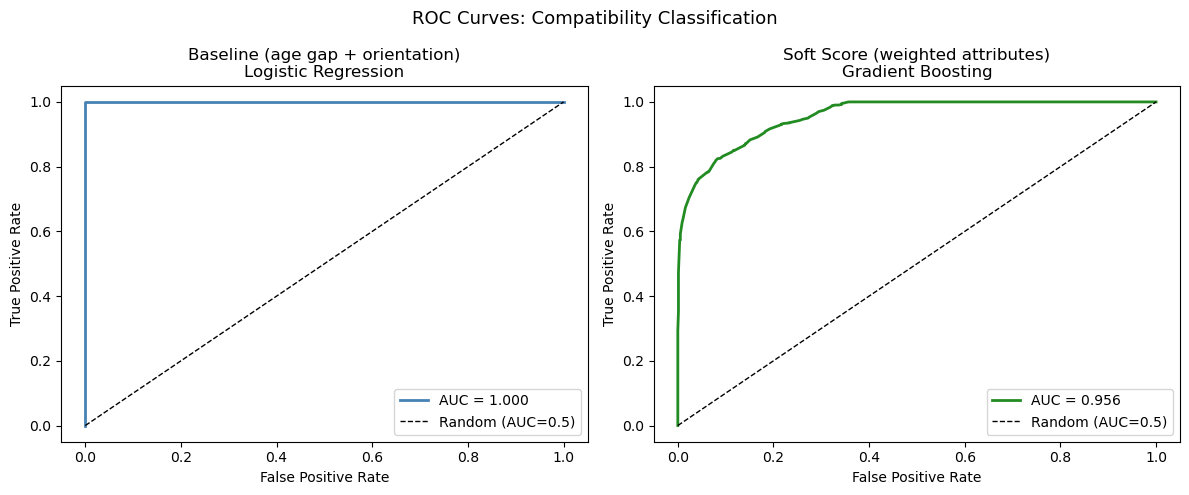

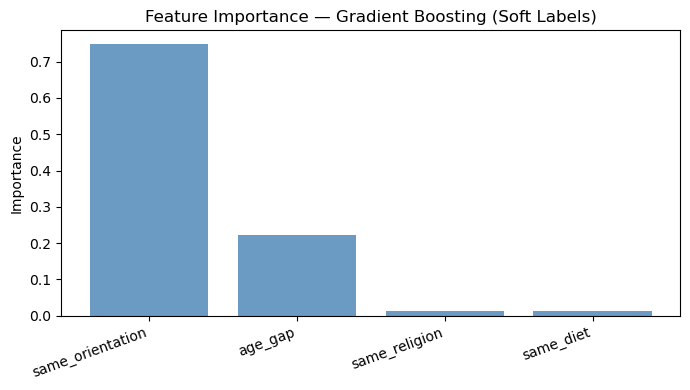

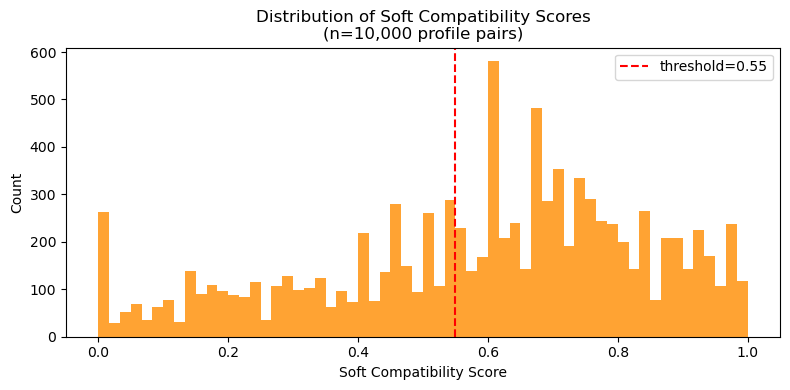

In [13]:
# ============================================================
# EXPERIMENT B: Attribute-Based Compatibility Scoring
# Baseline (age gap + orientation) → Soft (weighted attributes)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

okCupid = okCupid[okCupid['status'] == 'single'].reset_index(drop=True)
print(f"Single profiles: {len(okCupid)}")

# Clean income (-1 = not disclosed → NaN)
okCupid['income'] = okCupid['income'].replace(-1, np.nan)

# ============================================================
# PSEUDO-LABEL CONSTRUCTION
# ============================================================

# --- BASELINE: age gap + orientation match ---
def baseline_compatible(r1, r2):
    """Simple rule: same orientation, age gap <= 10 years."""
    age_ok = abs(r1['age'] - r2['age']) <= 10
    orient_ok = r1['orientation'] == r2['orientation']
    return int(age_ok and orient_ok)

# --- SOFT SCORE: weighted attribute agreement ---
def soft_score(r1, r2):
    """
    Weighted compatibility across multiple attributes.
    Returns a float in [0, 1].
    """
    score = 0.0
    total_weight = 0.0

    # Age gap (weight=2): score decays linearly up to 15yr gap
    w = 2.0
    age_gap = abs(r1['age'] - r2['age'])
    score += w * max(0, 1 - age_gap / 15)
    total_weight += w

    # Orientation match (weight=3): hard requirement
    w = 3.0
    if pd.notna(r1['orientation']) and pd.notna(r2['orientation']):
        score += w * int(r1['orientation'] == r2['orientation'])
        total_weight += w

    # Religion (weight=1.5): exact match
    w = 1.5
    if pd.notna(r1['religion']) and pd.notna(r2['religion']):
        # Normalize: strip qualifiers like "but not too serious about it"
        rel1 = r1['religion'].split(' and ')[0].split(' but ')[0].strip()
        rel2 = r2['religion'].split(' and ')[0].split(' but ')[0].strip()
        score += w * int(rel1 == rel2)
        total_weight += w

    # Diet (weight=1): exact match
    w = 1.0
    if pd.notna(r1['diet']) and pd.notna(r2['diet']):
        diet1 = r1['diet'].replace('strictly ', '').replace('mostly ', '').strip()
        diet2 = r2['diet'].replace('strictly ', '').replace('mostly ', '').strip()
        score += w * int(diet1 == diet2)
        total_weight += w

    # Education level (weight=1): within 1 level
    edu_order = {
        'graduated from high school': 1,
        'working on college/university': 2,
        'graduated from college/university': 3,
        'working on masters program': 4,
        'graduated from masters program': 5,
        'working on ph.d program': 6,
        'graduated from ph.d program': 7,
        'graduated from law school': 6,
        'graduated from med school': 6,
        'working on space camp': 2,  # joke answer
    }
    w = 1.0
    e1 = edu_order.get(r1.get('education', ''), None)
    e2 = edu_order.get(r2.get('education', ''), None)
    if e1 and e2:
        score += w * max(0, 1 - abs(e1 - e2) / 3)
        total_weight += w

    return score / total_weight if total_weight > 0 else 0.0

# ============================================================
# SAMPLE PAIRS (stratified: ~50% compatible)
# ============================================================
SAMPLE_N = 3000  # profiles to sample from
N_PAIRS = 10000  # pairs to evaluate

sample = okCupid.sample(SAMPLE_N, random_state=RANDOM_SEED).reset_index(drop=True)

print("Building pairs and computing labels...")
pairs = []
for _ in range(N_PAIRS * 3):  # oversample to hit target
    i, j = np.random.choice(SAMPLE_N, 2, replace=False)
    r1, r2 = sample.iloc[i], sample.iloc[j]
    
    baseline_label = baseline_compatible(r1, r2)
    soft = soft_score(r1, r2)
    soft_label = int(soft >= 0.55)  # threshold at 55th percentile
    
    pairs.append({
        'i': i, 'j': j,
        'age_i': r1['age'], 'age_j': r2['age'],
        'age_gap': abs(r1['age'] - r2['age']),
        'same_orientation': int(r1['orientation'] == r2['orientation']),
        'same_religion': int(
            pd.notna(r1['religion']) and pd.notna(r2['religion']) and
            r1['religion'].split(' but ')[0] == r2['religion'].split(' but ')[0]
        ),
        'same_diet': int(
            pd.notna(r1['diet']) and pd.notna(r2['diet']) and
            r1['diet'].replace('strictly','').replace('mostly','').strip() ==
            r2['diet'].replace('strictly','').replace('mostly','').strip()
        ),
        'soft_score': soft,
        'baseline_label': baseline_label,
        'soft_label': soft_label,
    })

pairs_df = pd.DataFrame(pairs).drop_duplicates(subset=['i','j']).head(N_PAIRS)
print(f"Pairs built: {len(pairs_df)}")
print(f"Baseline label balance: {pairs_df['baseline_label'].value_counts(normalize=True).to_dict()}")
print(f"Soft label balance:     {pairs_df['soft_label'].value_counts(normalize=True).to_dict()}")

# ============================================================
# FEATURE MATRIX
# ============================================================
feature_cols = ['age_gap', 'same_orientation', 'same_religion', 'same_diet']
X = pairs_df[feature_cols].values

# ============================================================
# MODEL A: Logistic Regression on BASELINE labels
# ============================================================
print("\n--- Logistic Regression (Baseline labels) ---")
y_base = pairs_df['baseline_label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y_base, test_size=0.2, random_state=RANDOM_SEED, stratify=y_base)

lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_base.fit(X_train, y_train)
y_prob_base = lr_base.predict_proba(X_test)[:, 1]
print(f"AUC (baseline): {roc_auc_score(y_test, y_prob_base):.4f}")
print(classification_report(y_test, lr_base.predict(X_test)))

# ============================================================
# MODEL B: Gradient Boosting on SOFT labels
# ============================================================
print("\n--- Gradient Boosting (Soft labels) ---")
y_soft = pairs_df['soft_label'].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_soft, test_size=0.2, random_state=RANDOM_SEED, stratify=y_soft)

gb_soft = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_SEED)
gb_soft.fit(X_train_s, y_train_s)
y_prob_soft = gb_soft.predict_proba(X_test_s)[:, 1]
print(f"AUC (soft): {roc_auc_score(y_test_s, y_prob_soft):.4f}")
print(classification_report(y_test_s, gb_soft.predict(X_test_s)))

# ============================================================
# VISUALIZATION 1: ROC curves comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC Curves: Compatibility Classification', fontsize=13)

for ax, y_t, y_p, title, color in zip(
    axes,
    [y_test, y_test_s],
    [y_prob_base, y_prob_soft],
    ['Baseline (age gap + orientation)\nLogistic Regression',
     'Soft Score (weighted attributes)\nGradient Boosting'],
    ['steelblue', 'forestgreen']
):
    fpr, tpr, _ = roc_curve(y_t, y_p)
    auc = roc_auc_score(y_t, y_p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 2: Feature importance (Gradient Boosting)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
importances = gb_soft.feature_importances_
idx = np.argsort(importances)[::-1]
ax.bar(range(len(feature_cols)), importances[idx], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in idx], rotation=20, ha='right')
ax.set_title('Feature Importance — Gradient Boosting (Soft Labels)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 3: Soft score distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs_df['soft_score'], bins=60, color='darkorange', alpha=0.8, edgecolor='none')
ax.axvline(0.55, color='red', linestyle='--', lw=1.5, label='threshold=0.55')
ax.set_xlabel('Soft Compatibility Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Soft Compatibility Scores\n(n=10,000 profile pairs)')
ax.legend()
plt.tight_layout()
plt.savefig('soft_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()


Using device: cuda


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 19019.86it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
Sentiment sample size: 2000


Encoding sentiment: 100%|██████████| 63/63 [00:28<00:00,  2.19it/s]


Affect vectors shape: (2000, 3)


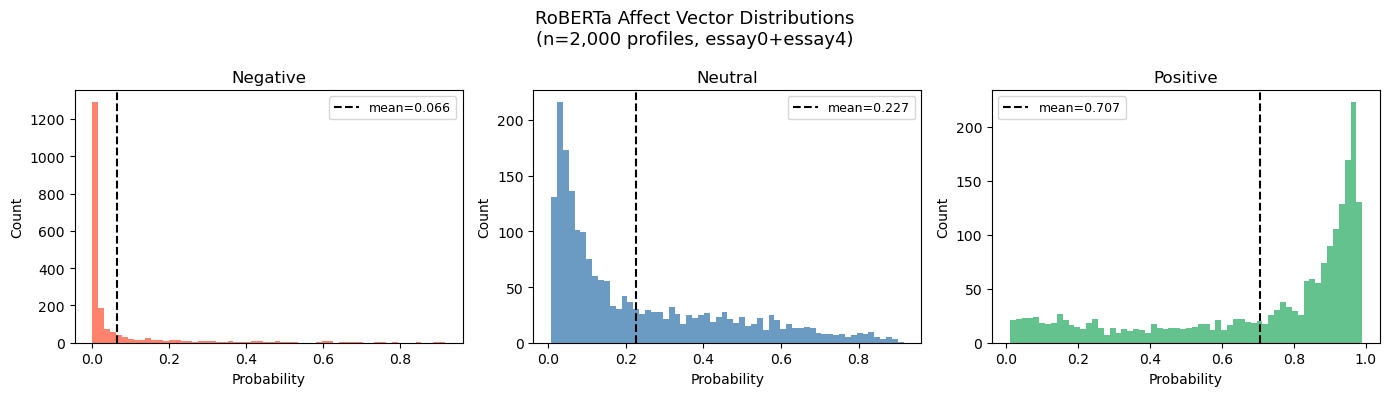

Saved: affect_distributions.png

Affect vector summary:
        neg_prob   neu_prob   pos_prob
count  2000.0000  2000.0000  2000.0000
mean      0.0656     0.2273     0.7071
std       0.1453     0.2217     0.3016
min       0.0013     0.0071     0.0098
25%       0.0043     0.0492     0.5187
50%       0.0087     0.1314     0.8545
75%       0.0343     0.3654     0.9445
max       0.9164     0.9164     0.9911


In [14]:
# ============================================================
# STEP 1: RoBERTa Sentiment — Per-Profile Affect Vectors
# Model: cardiffnlp/twitter-roberta-base-sentiment-latest
# Outputs a 3D vector [negative, neutral, positive] per profile.
# We use the full 3-vector (not a scalar) because downstream
# compatibility benefits from matching emotional *registers*
# — e.g., both high-positive vs. one cynical — which a scalar
# collapses. Cosine similarity between two affect vectors is
# used as the sentiment_sim feature in the re-ranker.
# ============================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

RANDOM_SEED_STEP12 = 123   # fresh held-out draw, distinct from Exp A (42) and B (42)
SENTIMENT_N        = 2000  # profiles for sentiment encoding
BATCH_SIZE         = 32    # safe for 4GB VRAM with roberta-base

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load model ──────────────────────────────────────────────
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
sent_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
sent_model.eval()
print(f"Labels: {sent_model.config.id2label}")
# Expected: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# ── Sample a fresh held-out set ──────────────────────────────
# okCupid already has 'profile_text' from Cell 11.
# We re-sample with a different seed so this set doesn't overlap
# with the Exp A (seed=42, n=2000) sample in expectation.
sentiment_sample = (
    okCupid[okCupid['profile_text'].str.len() > 50]
    .sample(SENTIMENT_N, random_state=RANDOM_SEED_STEP12)
    .reset_index(drop=True)
)
texts_sent = sentiment_sample['profile_text'].tolist()
print(f"Sentiment sample size: {len(texts_sent)}")

# ── Batch inference ──────────────────────────────────────────
def get_affect_vectors(texts, tokenizer, model, batch_size, device):
    """
    Returns numpy array of shape (N, 3): [neg_prob, neu_prob, pos_prob]
    Truncates each text to 128 tokens — sufficient for short profiles
    and keeps memory well within 4GB VRAM.
    """
    all_probs = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Encoding sentiment"):
        batch = texts[start : start + batch_size]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits          # (B, 3)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)  # (N, 3)

affect_vecs = get_affect_vectors(texts_sent, tokenizer, sent_model, BATCH_SIZE, device)
print(f"Affect vectors shape: {affect_vecs.shape}")   # (2000, 3)

# ── Store in dataframe for Step 2 ───────────────────────────
sentiment_sample['neg_prob'] = affect_vecs[:, 0]
sentiment_sample['neu_prob'] = affect_vecs[:, 1]
sentiment_sample['pos_prob'] = affect_vecs[:, 2]

# ── Visualize affect distribution across profiles ────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RoBERTa Affect Vector Distributions\n(n=2,000 profiles, essay0+essay4)', fontsize=13)

for ax, col, color, label in zip(
    axes,
    ['neg_prob', 'neu_prob', 'pos_prob'],
    ['tomato', 'steelblue', 'mediumseagreen'],
    ['Negative', 'Neutral', 'Positive']
):
    ax.hist(sentiment_sample[col], bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(sentiment_sample[col].mean(), color='black', linestyle='--', lw=1.5,
               label=f'mean={sentiment_sample[col].mean():.3f}')
    ax.set_title(label)
    ax.set_xlabel('Probability')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('affect_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: affect_distributions.png")

# ── Summary stats ────────────────────────────────────────────
print("\nAffect vector summary:")
print(sentiment_sample[['neg_prob','neu_prob','pos_prob']].describe().round(4).to_string())

Encoding held-out profiles with SBERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3479.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:07<00:00,  4.38it/s]


SBERT vecs shape: (2000, 384)
Pairs after removing self-pairs: 4996

=== Cross-Signal Correlation Results ===
SBERT sim vs. soft compatibility:
  Pearson  r = 0.0206  (p=1.4549e-01)
  Spearman r = 0.0207  (p=1.4346e-01)

Sentiment sim vs. soft compatibility:
  Pearson  r = 0.0036  (p=8.0168e-01)
  Spearman r = 0.0075  (p=5.9491e-01)


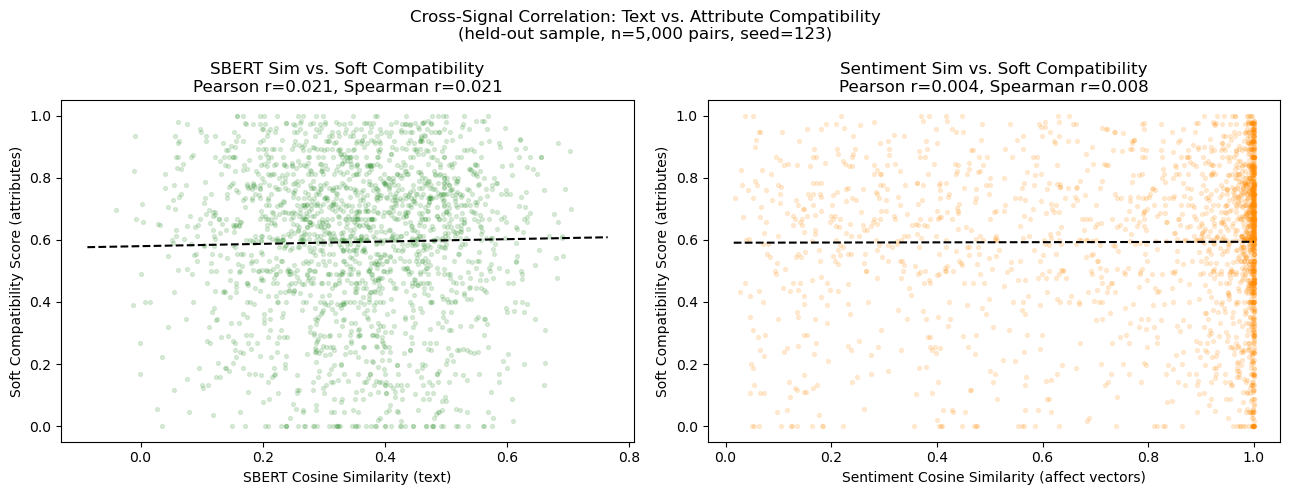

Saved: cross_signal_correlation.png


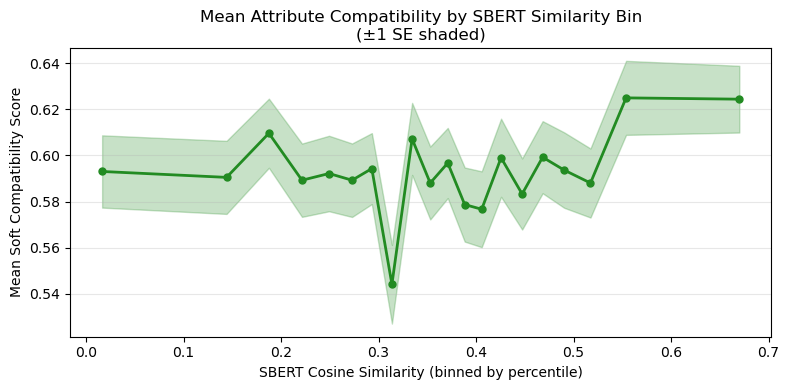

Saved: binned_correlation.png

=== Correlation Summary ===
                Signal Pair  Pearson r Pearson p  Spearman r Spearman p
    SBERT sim → soft compat     0.0206  1.45e-01      0.0207   1.43e-01
Sentiment sim → soft compat     0.0036  8.02e-01      0.0075   5.95e-01


In [15]:
# ============================================================
# STEP 2: Cross-Signal Correlation
# SBERT pairwise similarity vs. soft compatibility score
# on the SAME held-out pairs (seed=123).
#
# Core question: are semantically similar profiles (by text)
# also attribute-compatible? If yes → text + attributes are
# redundant. If weak/no correlation → they capture orthogonal
# signals, which motivates hybrid fusion.
# ============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

N_PAIRS_STEP2 = 5000   # pairs to sample from the 2000-profile held-out set

# ── Re-use sentiment_sample (seed=123, n=2000) ───────────────
# This is our held-out set for both signals.

# ── 2a: SBERT embeddings on the held-out set ─────────────────
print("Encoding held-out profiles with SBERT...")
sbert_model_s2 = SentenceTransformer('all-MiniLM-L6-v2', device=device)

sbert_vecs_s2 = sbert_model_s2.encode(
    texts_sent,          # same 2000 profiles as affect_vecs
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"SBERT vecs shape: {sbert_vecs_s2.shape}")   # (2000, 384)

# ── 2b: Sample random pairs and compute both signals ─────────
rng = np.random.default_rng(RANDOM_SEED_STEP12)
idx_i = rng.integers(0, SENTIMENT_N, size=N_PAIRS_STEP2)
idx_j = rng.integers(0, SENTIMENT_N, size=N_PAIRS_STEP2)

# Remove self-pairs
mask = idx_i != idx_j
idx_i, idx_j = idx_i[mask], idx_j[mask]
idx_i, idx_j = idx_i[:N_PAIRS_STEP2], idx_j[:N_PAIRS_STEP2]
print(f"Pairs after removing self-pairs: {len(idx_i)}")

# ── SBERT cosine similarity per pair ─────────────────────────
sbert_pair_sims = np.array([
    cos_sim(sbert_vecs_s2[i].reshape(1, -1),
            sbert_vecs_s2[j].reshape(1, -1))[0, 0]
    for i, j in zip(idx_i, idx_j)
])

# ── Soft compatibility score per pair ─────────────────────────
# Reuse the soft_score() function defined in Experiment B (Cell 13).
rows = sentiment_sample  # the 2000-profile dataframe

soft_scores_s2 = np.array([
    soft_score(rows.iloc[i], rows.iloc[j])
    for i, j in zip(idx_i, idx_j)
])

# ── Sentiment cosine similarity per pair ─────────────────────
# Cosine similarity between two 3D affect vectors.
affect_pair_sims = np.array([
    cos_sim(affect_vecs[i].reshape(1, -1),
            affect_vecs[j].reshape(1, -1))[0, 0]
    for i, j in zip(idx_i, idx_j)
])

# ── Correlation analysis ──────────────────────────────────────
r_pearson,  p_pearson  = pearsonr(sbert_pair_sims,   soft_scores_s2)
r_spearman, p_spearman = spearmanr(sbert_pair_sims,  soft_scores_s2)
r_sent_p,   p_sent_p   = pearsonr(affect_pair_sims,  soft_scores_s2)
r_sent_s,   p_sent_s   = spearmanr(affect_pair_sims, soft_scores_s2)

print("\n=== Cross-Signal Correlation Results ===")
print(f"SBERT sim vs. soft compatibility:")
print(f"  Pearson  r = {r_pearson:.4f}  (p={p_pearson:.4e})")
print(f"  Spearman r = {r_spearman:.4f}  (p={p_spearman:.4e})")
print(f"\nSentiment sim vs. soft compatibility:")
print(f"  Pearson  r = {r_sent_p:.4f}  (p={p_sent_p:.4e})")
print(f"  Spearman r = {r_sent_s:.4f}  (p={p_sent_s:.4e})")

# ── Visualization 1: Scatter — SBERT sim vs. soft score ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Signal Correlation: Text vs. Attribute Compatibility\n(held-out sample, n=5,000 pairs, seed=123)', fontsize=12)

# Subsample for scatter readability
plot_n = 2000
rng2 = np.random.default_rng(0)
plot_idx = rng2.choice(len(sbert_pair_sims), size=plot_n, replace=False)

ax = axes[0]
ax.scatter(
    sbert_pair_sims[plot_idx], soft_scores_s2[plot_idx],
    alpha=0.15, s=8, color='forestgreen'
)
# Trend line
m, b = np.polyfit(sbert_pair_sims, soft_scores_s2, 1)
xs = np.linspace(sbert_pair_sims.min(), sbert_pair_sims.max(), 100)
ax.plot(xs, m * xs + b, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('SBERT Cosine Similarity (text)')
ax.set_ylabel('Soft Compatibility Score (attributes)')
ax.set_title(f'SBERT Sim vs. Soft Compatibility\nPearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}')

ax = axes[1]
ax.scatter(
    affect_pair_sims[plot_idx], soft_scores_s2[plot_idx],
    alpha=0.15, s=8, color='darkorange'
)
m2, b2 = np.polyfit(affect_pair_sims, soft_scores_s2, 1)
xs2 = np.linspace(affect_pair_sims.min(), affect_pair_sims.max(), 100)
ax.plot(xs2, m2 * xs2 + b2, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Sentiment Cosine Similarity (affect vectors)')
ax.set_ylabel('Soft Compatibility Score (attributes)')
ax.set_title(f'Sentiment Sim vs. Soft Compatibility\nPearson r={r_sent_p:.3f}, Spearman r={r_sent_s:.3f}')

plt.tight_layout()
plt.savefig('cross_signal_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cross_signal_correlation.png")

# ── Visualization 2: Binned SBERT sim → mean soft score ──────
# Cleaner way to see any monotonic relationship even if noisy.
fig, ax = plt.subplots(figsize=(8, 4))

n_bins = 20
bins = np.percentile(sbert_pair_sims, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(sbert_pair_sims, bins) - 1
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

bin_means  = [soft_scores_s2[bin_idx == k].mean()  for k in range(n_bins)]
bin_sems   = [soft_scores_s2[bin_idx == k].std() /
              np.sqrt((bin_idx == k).sum() + 1e-8)  for k in range(n_bins)]
bin_centers = [(bins[k] + bins[k+1]) / 2 for k in range(n_bins)]

ax.plot(bin_centers, bin_means, 'o-', color='forestgreen', lw=2, ms=5)
ax.fill_between(bin_centers,
                np.array(bin_means) - np.array(bin_sems),
                np.array(bin_means) + np.array(bin_sems),
                alpha=0.25, color='forestgreen')
ax.set_xlabel('SBERT Cosine Similarity (binned by percentile)')
ax.set_ylabel('Mean Soft Compatibility Score')
ax.set_title('Mean Attribute Compatibility by SBERT Similarity Bin\n(±1 SE shaded)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('binned_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: binned_correlation.png")

# ── Correlation summary table ─────────────────────────────────
corr_summary = pd.DataFrame({
    'Signal Pair': [
        'SBERT sim → soft compat',
        'Sentiment sim → soft compat'
    ],
    'Pearson r':  [round(r_pearson, 4),  round(r_sent_p, 4)],
    'Pearson p':  [f'{p_pearson:.2e}',   f'{p_sent_p:.2e}'],
    'Spearman r': [round(r_spearman, 4), round(r_sent_s, 4)],
    'Spearman p': [f'{p_spearman:.2e}',  f'{p_sent_s:.2e}'],
})
print("\n=== Correlation Summary ===")
print(corr_summary.to_string(index=False))
corr_summary.to_csv('cross_signal_correlation_summary.csv', index=False)